# Learnable degrees of freedom

The Student's t-distribution used in t-SNE has a single shape parameter, `dof`, that controls how heavy-tailed the similarity kernel is in the embedding space. Smaller values produce more heavy-tailed kernels, which expose finer cluster structure (Kobak et al., 2019); larger values approach a Gaussian kernel and produce tighter, more separated clusters.

In standard t-SNE, `dof` is fixed to `1`. openTSNE additionally lets you treat `dof` as a free parameter and learn it jointly with the embedding by passing `dof="auto"`. This notebook demonstrates how to use that and the caveats to be aware of.

In [1]:
from openTSNE import TSNE, TSNEEmbedding
from openTSNE import affinity, initialization

import utils

import gzip
import pickle

import numpy as np
import matplotlib.pyplot as plt

## Load data

We use the Macosko 2015 mouse retina data set, as in the other example notebooks. The preprocessed data set can be downloaded from http://file.biolab.si/opentsne/benchmark/macosko_2015.pkl.gz.

In [2]:
with gzip.open("data/macosko_2015.pkl.gz", "rb") as f:
    data = pickle.load(f)

x = data["pca_50"]
y = data["CellType1"].astype(str)

print("Data set contains %d samples with %d features" % x.shape)

Data set contains 44808 samples with 50 features


### A note on speed, and why we subsample

Learning `dof` jointly with the embedding requires the Barnes-Hut objective, and the BH kernel is substantially slower whenever `dof != 1`. The reason is in the inner loop: with `dof = 1`, the per-summary kernel reduces to a single `1 / (1 + d²)`; with any other value of `dof`, the kernel uses two `pow()` calls with a non-integer exponent (computed internally as `exp(y * log(x))`), which is roughly an order of magnitude more expensive than a division. The extra work needed to actually compute the `dof` gradient is small by comparison — the dominant cost is simply that `dof != 1` takes a different code path.

In practice this means a `dof="auto"` run can be 2–3× slower per iteration than the standard `dof=1` t-SNE on the same data, and the slowdown is *intrinsic to the heavy-tailed kernel* — running with any other fixed value of `dof` (e.g. `dof=0.5`) incurs essentially the same cost.

To keep this notebook responsive, we subsample the dataset to ~5,000 points below. The full Macosko 2015 set (44,808 points) runs fine but takes several minutes per `optimize` call with `dof="auto"`.

In [3]:
rng = np.random.default_rng(42)
sample_idx = rng.choice(x.shape[0], size=5000, replace=False)
x = x[sample_idx]
y = y[sample_idx]

print("Subsampled to %d samples with %d features" % x.shape)

Subsampled to 5000 samples with 50 features


## Fixed dof (standard t-SNE)

For reference, we first run t-SNE with the default `dof=1`. Learning `dof` requires the Barnes-Hut objective, so we explicitly set `negative_gradient_method="bh"` here too — that way the only thing that differs in the next run is whether `dof` is learned.

In [4]:
tsne_fixed = TSNE(
    perplexity=30,
    dof=1,
    negative_gradient_method="bh",
    n_jobs=8,
    random_state=42,
    verbose=True,
)
embedding_fixed = tsne_fixed.fit(x)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, negative_gradient_method='bh',
     random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 0.30 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.09 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=416.67 for 250 iterations...
Iteration   50, KL divergence 3.7923, 50 iterations in 0.9387 sec
Iteration  100, KL divergence 3.7599, 50 iterations in 0.9332 sec
Iteration  150, KL divergence 3.7720, 50 iterations in 0.9355 sec
Iteration  200, KL divergence 3.7727, 50 iterations in 0.9373 sec
Iteration  250, KL divergence 3.7728, 50 iterations in 0.9467 sec
   --> Time elapsed: 4.69 seconds
===> Runni

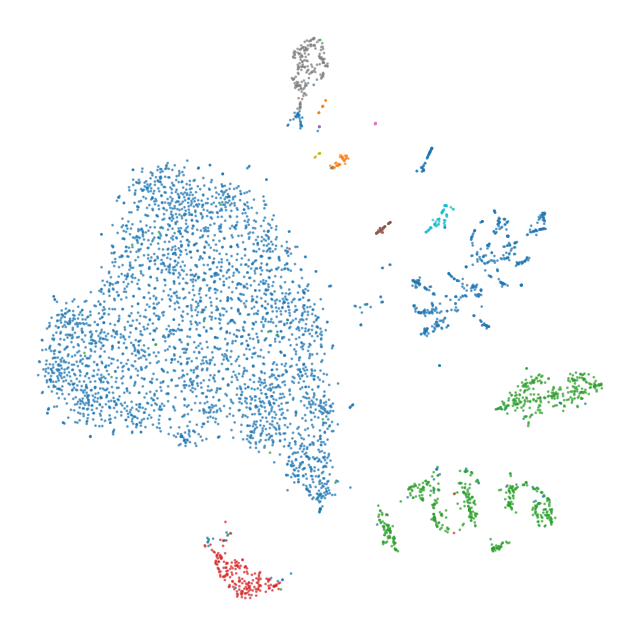

In [5]:
utils.plot(embedding_fixed, y, draw_legend=False)

## Learning dof jointly with the embedding

Passing `dof="auto"` lets the optimizer learn `dof` together with the embedding. The learned value is exposed on the embedding under the `dof_` attribute, following the scikit-learn trailing-underscore convention for learned attributes.

In [6]:
tsne_auto = TSNE(
    perplexity=30,
    dof="auto",
    negative_gradient_method="bh",
    n_jobs=8,
    random_state=42,
    verbose=True,
)
embedding_auto = tsne_auto.fit(x)

print(f"Learned dof: {embedding_auto.dof_:.3f}")

--------------------------------------------------------------------------------
TSNE(dof='auto', early_exaggeration=12, n_jobs=8, negative_gradient_method='bh',
     random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 0.29 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.09 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.00 seconds
===> Running optimization with exaggeration=12.00, lr=416.67 for 250 iterations...
Iteration   50, KL divergence 3.4586, 50 iterations in 2.8552 sec
Iteration  100, KL divergence 3.4138, 50 iterations in 2.6234 sec
Iteration  150, KL divergence 3.3894, 50 iterations in 2.8188 sec
Iteration  200, KL divergence 3.3821, 50 iterations in 2.6345 sec
Iteration  250, KL divergence 3.3777, 50 iterations in 2.6317 sec
   --> Time elapsed: 13.56 secon

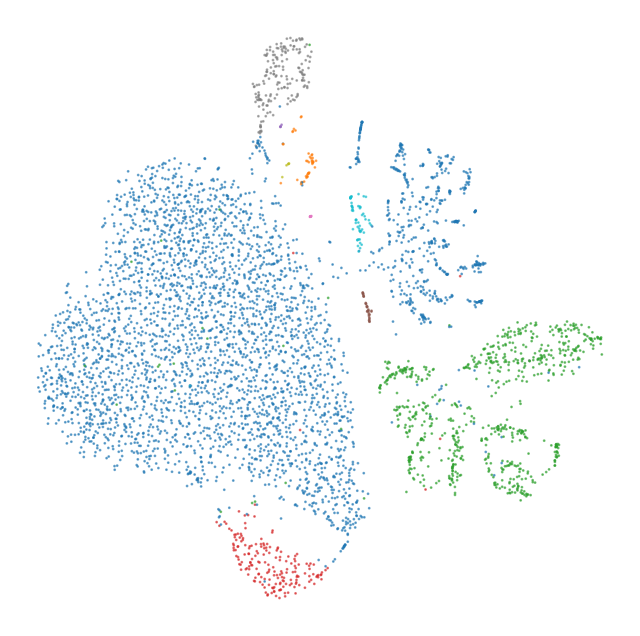

In [7]:
utils.plot(embedding_auto, y, draw_legend=False)

You can seed the optimization with `initial_dof`. This only has an effect when `dof="auto"`; with a fixed `dof` it is ignored and a `UserWarning` is emitted.

In [8]:
tsne_auto_seeded = TSNE(
    perplexity=30,
    dof="auto",
    initial_dof=0.5,
    negative_gradient_method="bh",
    n_jobs=8,
    random_state=42,
)
embedding_auto_seeded = tsne_auto_seeded.fit(x)
print(f"Learned dof (seeded): {embedding_auto_seeded.dof_:.3f}")

Learned dof (seeded): 1.959


## Tracking dof during optimization

The `IterationState` passed to user callbacks exposes the current `dof` and its gradient. The snapshot embedding also carries a global iteration counter, `optimization_iters_`, which accumulates across consecutive `optimize` calls — so we use it as the x-axis here rather than `state.iteration`, which resets on every `optimize` call.

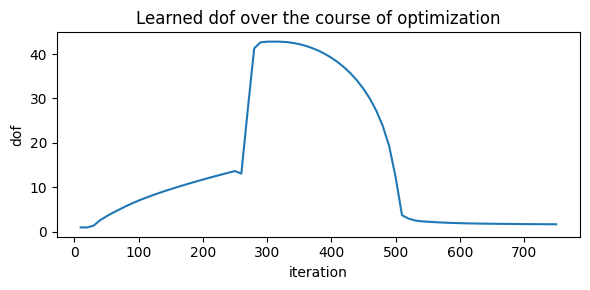

In [9]:
dof_history = []

def record_dof(state):
    dof_history.append((state.embedding.optimization_iters_, state.dof))

tsne_traced = TSNE(
    perplexity=30,
    dof="auto",
    negative_gradient_method="bh",
    callbacks=record_dof,
    callbacks_every_iters=10,
    n_jobs=8,
    random_state=42,
)
embedding_traced = tsne_traced.fit(x)

iters, dofs = zip(*dof_history)
plt.figure(figsize=(6, 3))
plt.plot(iters, dofs)
plt.xlabel("iteration")
plt.ylabel("dof")
plt.title("Learned dof over the course of optimization")
plt.tight_layout()

## Caveats

### Only the Barnes-Hut objective supports learning dof

The FFT accelerated negative-gradient kernels do not compute the gradient with respect to `dof`. Combining `dof="auto"` with `negative_gradient_method="fft"` will leave `dof` fixed at `initial_dof` (or `1.0`) and emit a warning. Use `negative_gradient_method="bh"` if you actually want `dof` to change.

Because Barnes-Hut is required, the usual scaling caveats apply: for very large data sets the FFT objective is much faster, and you may prefer to fix `dof` rather than learn it.

### Switching from a fixed dof to `"auto"` resumes from the fixed value

`embedding.dof_` is always set after `optimize` — even when `dof` was a fixed numeric value, in which case it simply equals that fixed value. A subsequent `optimize` call with `dof="auto"` then resumes from the value the embedding already carries rather than restarting from `initial_dof`.

We can see this directly: warm up with `dof=5` for a couple hundred iterations, then switch to `dof="auto"` and trace `dof` across both `optimize` calls. The trajectory is flat at 5 during the fixed phase and starts learning *from* 5 when auto kicks in.

Final dof: 1.595  (started learning from 5, not 1)


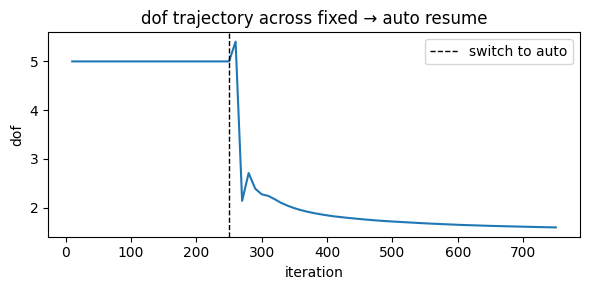

In [10]:
affinities = affinity.PerplexityBasedNN(x, perplexity=30, n_jobs=8, random_state=42)
init = initialization.pca(x, random_state=42)

resume_history = []

def record_resume(state):
    resume_history.append((state.embedding.optimization_iters_, state.dof))

embedding = TSNEEmbedding(init, affinities, negative_gradient_method="bh", n_jobs=8)
embedding = embedding.optimize(
    n_iter=250,
    exaggeration=12,
    dof=5,
    callbacks=record_resume,
    callbacks_every_iters=10,
)
fixed_phase_end = embedding.optimization_iters_
embedding = embedding.optimize(
    n_iter=500,
    dof="auto",
    callbacks=record_resume,
    callbacks_every_iters=10,
)

print(f"Final dof: {embedding.dof_:.3f}  (started learning from 5, not 1)")

iters, dofs = zip(*resume_history)
plt.figure(figsize=(6, 3))
plt.plot(iters, dofs)
plt.axvline(fixed_phase_end, color="k", linestyle="--", linewidth=1, label="switch to auto")
plt.xlabel("iteration")
plt.ylabel("dof")
plt.title("dof trajectory across fixed → auto resume")
plt.legend()
plt.tight_layout()

This is usually what you want: it lets you warm up the embedding with a fixed, heavy-tailed kernel and then hand control over to the optimizer. It is worth being aware of when chaining `optimize` calls though, particularly if you expect `"auto"` to always start from `1`.

### Switching from `"auto"` to a fixed dof immediately overrides the learned value

The reverse direction has no such resume behavior: a subsequent `optimize` call with a numeric `dof` ignores the previously learned value and uses the new fixed value from the very first iteration. The embedding's `dof_` attribute is updated accordingly.

In [11]:
embedding = TSNEEmbedding(init, affinities, negative_gradient_method="bh", n_jobs=8)
embedding = embedding.optimize(n_iter=250, exaggeration=12, dof="auto")
print(f"After auto phase: dof_ = {embedding.dof_:.3f}")

embedding = embedding.optimize(n_iter=500, dof=7)
print(f"After fixed phase: dof_ = {embedding.dof_:.3f}")

After auto phase: dof_ = 13.721
After fixed phase: dof_ = 7.000


## References

- Kobak, D., Linderman, G., Steinerberger, S., Kluger, Y., & Berens, P. (2019). ["Heavy-tailed kernels reveal a finer cluster structure in t-SNE visualisations."](https://arxiv.org/abs/1902.05804) ECML PKDD.